<a href="https://colab.research.google.com/github/frafrad/Flipped-Classroom_S4_FRADIANI-MURGANTE-FRANCESCA/blob/main/Flipped_Classroom_S4_FRADIANI_MURGANTE.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**EXERCISE 1:** K-means on the Penguins dataset
- **a.1)** I need to keep only the numeric columns of penguins and check **how many missing values each column has** (.isna().sum())
- **a.2)** I have to drop rows with missing values (.dropna()) + confirm the resulting dataframe is clean (no NaN left).

In [9]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import confusion_matrix
from sklearn.metrics.cluster import adjusted_rand_score
from sklearn.preprocessing import LabelEncoder, StandardScaler

penguins = sns.load_dataset('penguins')
num_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
# con questo comando ho selezionato solo le colonne che contengono numeri

# a.1 check missing values per column
print(penguins[num_cols].isna().sum())
# a.2 dropna() and confirm the data is clean
penguins_clean = penguins[num_cols].dropna()

print(penguins_clean.isna().sum())

bill_length_mm       2
bill_depth_mm        2
flipper_length_mm    2
body_mass_g          2
dtype: int64
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
dtype: int64


**b)** **Normalization**: the 4 numeric columns live on very different scales (mm, g...). Normalize them with **StandardScaler** (mean 0, standard deviation 1) before clustering.

In [10]:
# b) normalize the numeric columns with StandardScaler
penguins_scaled = StandardScaler().fit_transform(penguins_clean)
# .fit_transform mi calcola media e varianza e trasforma i dati in array NumPy
penguins_scaled_df = pd.DataFrame(penguins_scaled, columns=num_cols)
# ho riconvertito in DataFrame Pandas e ho riassegnato i nomi originali delle colonne a penguins_scaled_df
print(penguins_scaled_df)
# per ogni valore è stato fatto (valore originale-media della colonna)/(deviazione standard della colonna)
# in modo tale che fossero poi confrontabili come clusters col k-means

     bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g
0         -0.884499       0.785449          -1.418347    -0.564142
1         -0.811126       0.126188          -1.062250    -0.501703
2         -0.664380       0.430462          -0.421277    -1.188532
3         -1.324737       1.089724          -0.563715    -0.938776
4         -0.847812       1.748985          -0.777373    -0.689020
..              ...            ...                ...          ...
337        0.601305      -1.750171           0.931890     0.903175
338        0.527932      -1.445897           1.003109     0.809516
339        1.188289      -0.735923           1.501644     1.933419
340        0.234440      -1.192335           0.789451     1.246590
341        1.096572      -0.533073           0.860670     1.496346

[342 rows x 4 columns]


**c)** Apply **k-means** with k=3 (there are 3 penguin species) to the normalized columns. Store the resulting labels in a variable **kmeans_labels**

In [11]:
# c) apply KMeans with k=3 on the normalized data
kmeans = KMeans(n_clusters=3, random_state=42)
# ho impostato un modello per cercare 3 gruppi
# il random_state serve per assicurarsi che ogni volta che rilanci la cella ottieni sempre lo stesso identico risultato
kmeans_labels = kmeans.fit_predict(penguins_scaled_df)
# calcolo i centroidi sui dati normalizzati + assegno a ogni pinguino un'etichetta 0,1,2 (cluster 1, cluster 2, cluster 3)
# print(kmeans_labels)

[2 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 0 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 0 2 2 2 2 2 0 2 2 2 0 2 2 2 2 2 2 2 0 2 2 2 2 2 2 2 0 2 2 2 0 2
 0 2 2 2 0 2 0 2 2 2 2 2 2 2 2 2 0 2 2 2 0 2 2 2 0 2 0 2 2 2 2 2 2 2 0 2 0
 2 0 2 0 2 2 2 2 2 2 2 0 2 2 2 2 2 0 2 0 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 0 0 0 0 0 0 0 2 0 2 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1]


- **d.1)** Add the cluster labels as a new column in your (unscaled) dataframe (penguins_clean)
- **d.2)** Make a scatterplot between* bill_length_mm* and *flipper_length_mm* colored by kmeans_labels,
- **d.3)** Also make two pairplots of the 4  numeric variables:
- one colored by the real species
- one colored by kmeans_labels

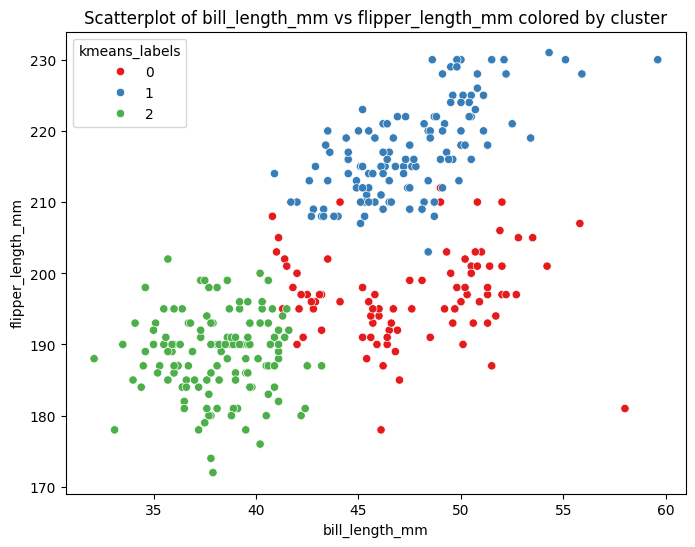

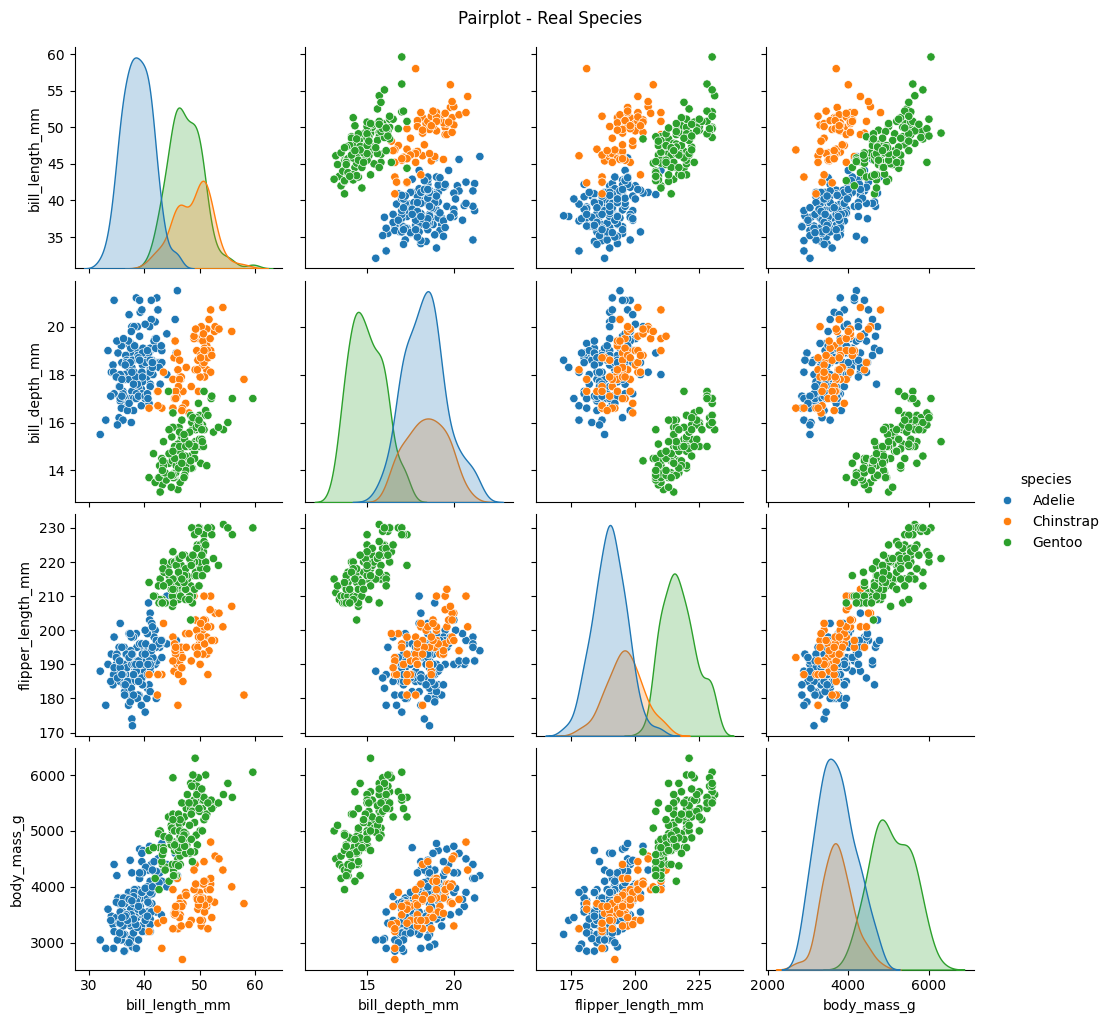

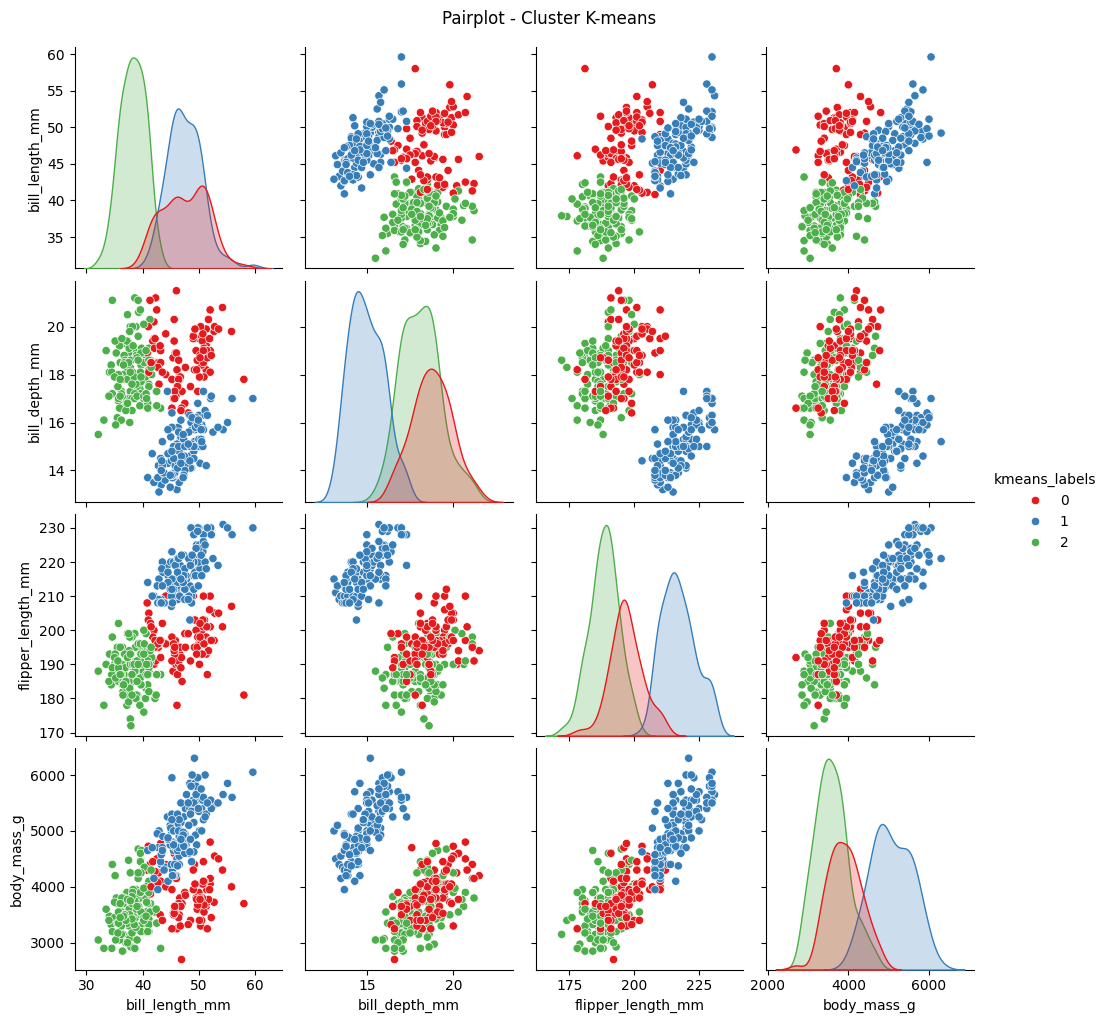

In [17]:
# d.1) add kmeans_labels to penguins_clean

penguins_clean['kmeans_labels'] = kmeans_labels
penguins_clean['species'] = penguins.loc[penguins_clean.index, 'species']
#print(penguins_clean)

# d.2) plot bill_length_mm vs flipper_length_mm colored by cluster
plt.figure(figsize=(8,6))
sns.scatterplot(data= penguins_clean, x='bill_length_mm', y='flipper_length_mm', hue='kmeans_labels', palette='Set1')
plt.title('Scatterplot of bill_length_mm vs flipper_length_mm colored by cluster')
plt.show()

# d.3) make two pairplots (one hue='species', one hue=kmeans cluster)
sns.pairplot(penguins_clean[num_cols + ['species']], hue='species')
plt.suptitle('Pairplot - Real Species', y=1.02)
plt.show()

sns.pairplot(penguins_clean[num_cols + ['kmeans_labels']], hue='kmeans_labels', palette= 'Set1')
plt.suptitle('Pairplot - Cluster K-means', y=1.02)
plt.show()


**e)** Now compare the clusters found by k-means with the real species. Compute a confusion matrix (sklearn.metrics.confusion_matrix) between kmeans_labels and the real species, and the adjusted Rand score (adjusted_rand_score).

In [22]:
# e) confusion matrix and adjusted Rand score vs real 'species'
le = LabelEncoder()
species_encoded = le.fit_transform(penguins_clean['species'])
cm = confusion_matrix(species_encoded, penguins_clean['kmeans_labels'])
print("Confusion Matrix:\n", cm)
# righe: le specie che sono diventate numeri in ordine alfabetico
# colonne: colonna 0 -> cluster 0; colonna 1: cluster 1...
# riga 0 (Adelie): 127 pinguini associati al cluster 2, 24 al cluster 0
# riga 1 (Chinastrap): 63 pinguini associati al cluster 0, 5 al cluster 2
# riga 2 (Gentoo): tutti e 123 associati al cluster 1

ari = adjusted_rand_score(penguins_clean['species'], penguins_clean['kmeans_labels'])
print("\n Adjusted Rand Score:", ari)
# misura quanto l'assegnazione ai cluster coincide con la reale appartenenza alla specie

Confusion Matrix:
 [[ 24   0 127]
 [ 63   0   5]
 [  0 123   0]]

 Adjusted Rand Score: 0.7928369051321087


**f)** In a short comment or markdown cell:
- **does k-means recover the 3 species well?** Yes, adj equal to 0,79 means strongly correspondence between clusters of real species and of kmeans_labels
- **Which species seem to get confused with each other, if any? ** Gentoo specie is perfectly separated, some Adelie's penguins have been associated to Chinstrap's ones because they have similar body mass and flipper lengths.
- **Did normalizing the features change the result compared to using the raw values?** Yes, because if we didn't normalized, body mass will predominate all calculus, separating penguins only by their body mass and not by other features.

**EXERCISE 2:** Hierarchical clustering + a custom distance function
- **a)** check for missing values: use np.isnan(X).any() to confirm there are none

In [23]:
import numpy as np
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage
import matplotlib.pyplot as plt

X = np.array([[1, 2], [1, 4], [1, 0], [5, 6], [5, 3], [5, 0]])

# a) check for missing values with np.isnan(X).any()
print("Are there any missing values?", np.isnan(X).any())
#deve printare False perchè vedo chiaramente che non ci sono valori mancanti

Are there any missing values? False


**b)** Normalize X with **StandardScaler** before clustering (this should always be the default first step for any distance-based method).

In [25]:
# b)normalize X with StandardScaler
X_scaled = StandardScaler().fit_transform(X)
print("X_scaled:\n", X_scaled)

X_scaled:
 [[-1.         -0.23354968]
 [-1.          0.70064905]
 [-1.         -1.16774842]
 [ 1.          1.63484778]
 [ 1.          0.23354968]
 [ 1.         -1.16774842]]


**c)** Write a plain Python function euclidean_distance(p1, p2) without using numpy or sklearn, using only a for loop over the coordinates, that computes the Euclidean distance between two points (given as lists or tuples). Test it on euclidean_distance(X[0], X[3]) and check it against np.linalg.norm(X[0]-X[3]).

In [26]:
# c)  plain-Python euclidean_distance function using a for loop (no numpy/sklearn)
def euclidean_distance(p1, p2):
  quadratic_sum = 0
  for i in range(len(p1)):
    quadratic_sum += (p1[i]-p2[i])**2
  return quadratic_sum **0.5
#inizializzo il totale uguale a 0; per ogni ciclo prendo le coordinate x e y, ne faccio la differenza ed elevo al quadrato + lo sommo a quello precedente
#infine calcolo la radice finale
# test it
print(euclidean_distance(X[0], X[3]))
print(np.linalg.norm(X[0] - X[3]))
#questa è la funzione che farebbe la stessa cosa: i risultati sono uguali!

5.656854249492381
5.656854249492381


**d) **Apply Agglomerative Clustering with n_clusters=2 to the normalized X and plot the dendrogram using **scipy.cluster.hierarchy.dendrogram **and linkage.

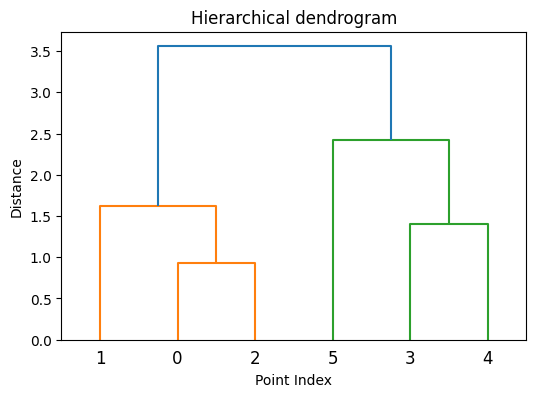

In [28]:
# d) agglomerative clustering on X_scaled + dendrogram
agglo = AgglomerativeClustering(n_clusters=2)
agglo_labels = agglo.fit_predict(X_scaled)
# calcolo la matrice linkage
linkage_matrix = linkage(X_scaled, method= 'ward')
plt.figure(figsize=(6,4))
dendrogram(linkage_matrix)
plt.title('Hierarchical dendrogram')
plt.xlabel('Point Index')
plt.ylabel('Distance')
plt.show()

**e) **Also apply** k-means** with n_clusters=2 to the same normalized data.

In [37]:
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans_labels = kmeans.fit_predict(X_scaled)
print(kmeans_labels)

[0 0 0 1 1 1]


- **f.1) **Compare the cluster labels obtained by agglomerative clustering and k-means — a**re they identical for this small dataset?**
- **f.2)** Print both label arrays, and make a **side-by-side scatterplot** of the original points colored by each method's labels.

[1 1 1 0 0 0]
[0 0 0 1 1 1]


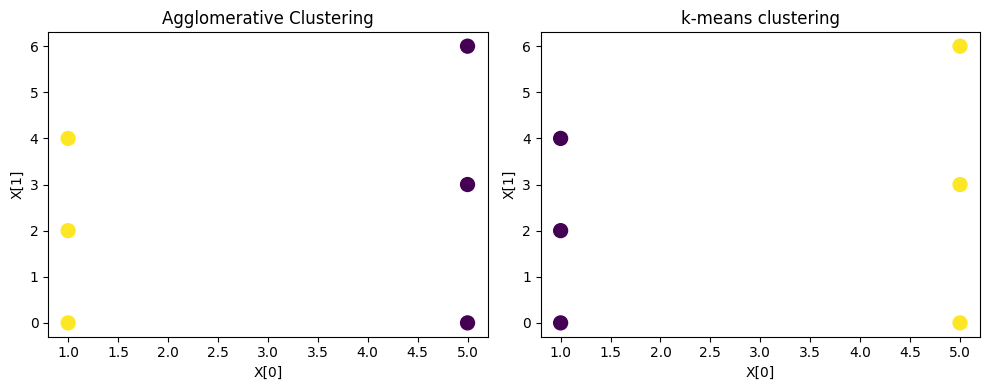

In [39]:
# f.1) compare both label arrays and make a side-by-side scatterplot
print(agglo_labels)
print(kmeans_labels)
# f.2) creo i due grafici affiancati
fig, axes = plt.subplots(1,2, figsize= (10,4))
# creo una figura divisa in 1 riga e 2 colonne (10 e 4 sono larghezza e altezza)
#Agglomerative Clustering - axes[0]
axes[0].scatter(X[:,0], X[:,1], c=agglo_labels, cmap='viridis', s=100)
#scatter = grafico a pallini; X[:,0] sono le righe della prima colonna di X; X[:,1] sono tutte le righe della seconda colonna
# c e cmap servono per i colori
# s serve per la dimensione dei pallini
axes[0].set_title("Agglomerative Clustering")
axes[0].set_xlabel("X[0]")
axes[0].set_ylabel("X[1]")

#k means - axes[1]
axes[1].scatter(X[:,0], X[:,1], c=kmeans_labels, cmap='viridis', s=100)
axes[1].set_title("k-means clustering")
axes[1].set_xlabel("X[0]")
axes[1].set_ylabel("X[1]")

plt.tight_layout()
# tight serve per mettere la spaziatura tra i due riquadri
plt.show()

**g)** Write a function **cluster_sizes(labels)** that takes an array of cluster labels and returns a **dictionary with the count of observations per cluster** and apply it to both clusterings.

In [41]:
# g) cluster_sizes function using a dictionary
def cluster_sizes(labels):
  counts = {}
  for label in labels:
    if label in counts:
      counts[label] +=1
    else:
      counts[label] =1
  return counts


print("Agglomerative cluster sizes:", cluster_sizes(agglo_labels))
print("K-means cluster sizes:", cluster_sizes(kmeans_labels))

Agglomerative cluster sizes: {np.int64(1): 3, np.int64(0): 3}
K-means cluster sizes: {np.int32(0): 3, np.int32(1): 3}


**EXERCISE 3:** Choosing the number of clusters with GMM + BIC
- a.1) Select **only the numeric columns** carat, depth, table, price into a new dataframe diamonds_num.
- a.2) Check for **missing values** (.isna().sum()) and drop any rows with NaN if needed, confirming the data is clean afterwards.

In [49]:
import seaborn as sns
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import mixture
from sklearn.preprocessing import StandardScaler

diamonds = sns.load_dataset('diamonds').sample(1000, random_state=42)

# a.1) select numeric columns into diamonds_num
num_cols = ['carat', 'depth', 'table', 'price']
diamonds_num = diamonds[num_cols].copy()
#print(diamonds_num)

# a.2) check missing values, dropna() and confirm it's clean
print(diamonds_num.isna().sum())
diamonds_num = diamonds_num.dropna()
print(diamonds_num)

carat    0
depth    0
table    0
price    0
dtype: int64
       carat  depth  table  price
1388    0.24   62.1   56.0    559
50052   0.58   60.0   57.0   2201
41645   0.40   62.1   55.0   1238
42377   0.43   60.8   57.0   1304
17244   1.55   62.3   55.0   6901
...      ...    ...    ...    ...
35207   0.33   61.6   55.0    891
15806   1.00   62.4   55.0   6324
45884   0.58   61.1   56.0   1719
22681   0.38   62.0   55.0    629
21429   1.18   59.7   58.0   9537

[1000 rows x 4 columns]


**b) **Plot the distribution of price (**histogram**) and mark the** mean and mean ± one standard deviation with vertical lines**

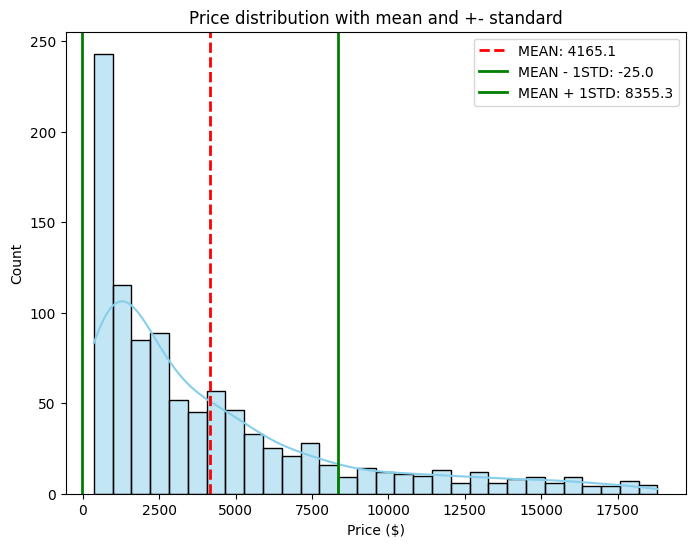

In [50]:
# b) histogram of 'price' with mean and mean +/- std lines
mean_price = diamonds_num['price'].mean()
std_price = diamonds_num['price'].std()

#creo istogramma
plt.figure(figsize= (8,6))
sns.histplot(diamonds_num['price'], kde=True, bins=30, color='skyblue')
#disegno istogramma con frequenze del prezzo e curva KDE
#linea verticale per la media
plt.axvline(mean_price, color= 'red', linestyle='--', linewidth=2, label=f'MEAN: {mean_price:.1f}')

#linea verticale per la media-standard e media+standard
plt.axvline(mean_price - std_price, color= 'green', linestyle='-', linewidth=2, label=f'MEAN - 1STD: {mean_price - std_price:.1f}')
plt.axvline(mean_price + std_price, color= 'green', linestyle='-', linewidth=2, label=f'MEAN + 1STD: {mean_price + std_price:.1f}')

plt.title('Price distribution with mean and +- standard')
plt.xlabel("Price ($)")
plt.ylabel("Count")
plt.legend()
plt.show()

**c) **(Normalize carat, depth, table and price are on very different scales (price ranges into the thousands of dollars, while depth/table are percentages around 50–70). Use **StandardScaler** before fitting the GMM — otherwise price alone will dominate the covariance structure the model is trying to fit.

In [51]:
# c) normalize the 4 numeric columns with StandardScaler
diamonds_scaled = StandardScaler().fit_transform(diamonds_num)
print(diamonds_scaled)

[[-1.19910658  0.24293476 -0.5945033  -0.86106479]
 [-0.50515554 -1.25622185 -0.16017886 -0.46899303]
 [-0.87254138  0.24293476 -1.02882775 -0.69893524]
 ...
 [-0.50515554 -0.47094934 -0.5945033  -0.58408352]
 [-0.91336203  0.17154635 -1.02882775 -0.8443504 ]
 [ 0.71946395 -1.47038708  0.27414559  1.28267469]]


- **d.1)** Fit a Gaussian Mixture Model on the normalized data for a range of number of components from 1 to 8
- **d.2)** **Store the BIC value for each in a list**
- **d.3) Plot BIC vs number of components**.

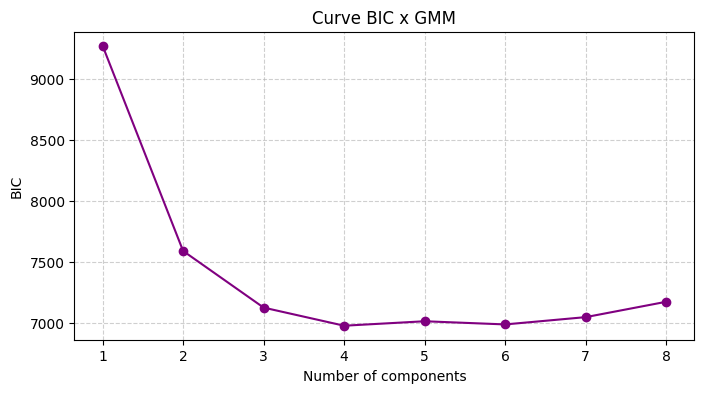

In [52]:
# d.1) Fit GMM for n_components = 1..8 on diamonds_scaled

bic = []
n_components_range = range(1, 9)
# d.2) store BIC values
for n in n_components_range:
  gmm = mixture.GaussianMixture(n_components=n, random_state=42)
  #creo il modello GMM con n componenti
  gmm.fit(diamonds_scaled)

  bic.append(gmm.bic(diamonds_scaled))
  #calcolo il bic e lo aggiungo alla lista

# d.3) plot BIC vs n_components
plt.figure(figsize=(8,4))
plt.plot(n_components_range, bic, marker='o', linestyle='-', color='purple')
plt.title("Curve BIC x GMM")
plt.xlabel("Number of components")
plt.ylabel("BIC")
plt.xticks(n_components_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()



**e) **Find the **number of components that minimizes the BIC**, and fit the final GMM model with that number of components. Store the predicted cluster labels in gmm_labels.

In [53]:
# e) Find the number of components that minimizes BIC and fit the final GMM
best_idx = np.argmin(bic) #restituisce l'indice della lista bic con il valore più piccolo
best_n = list(n_components_range)[best_idx] #estrae quel numero
print("Best number of components:", best_n)

final_gmm = mixture.GaussianMixture(n_components=best_n, random_state=42)
gmm_labels = final_gmm.fit_predict(diamonds_scaled)

Best number of components: 4


- **f.1)** Add **gmm_labels** as a **new column to your** **diamonds_num**
- f.2) create a **pairplot** (sns.pairplot) of carat, depth, table, price, colored by gmm_labels (hue).
- f.3) Make a **jointplot** (sns.jointplot) of carat vs price to zoom into the relationship driving most of the clustering.

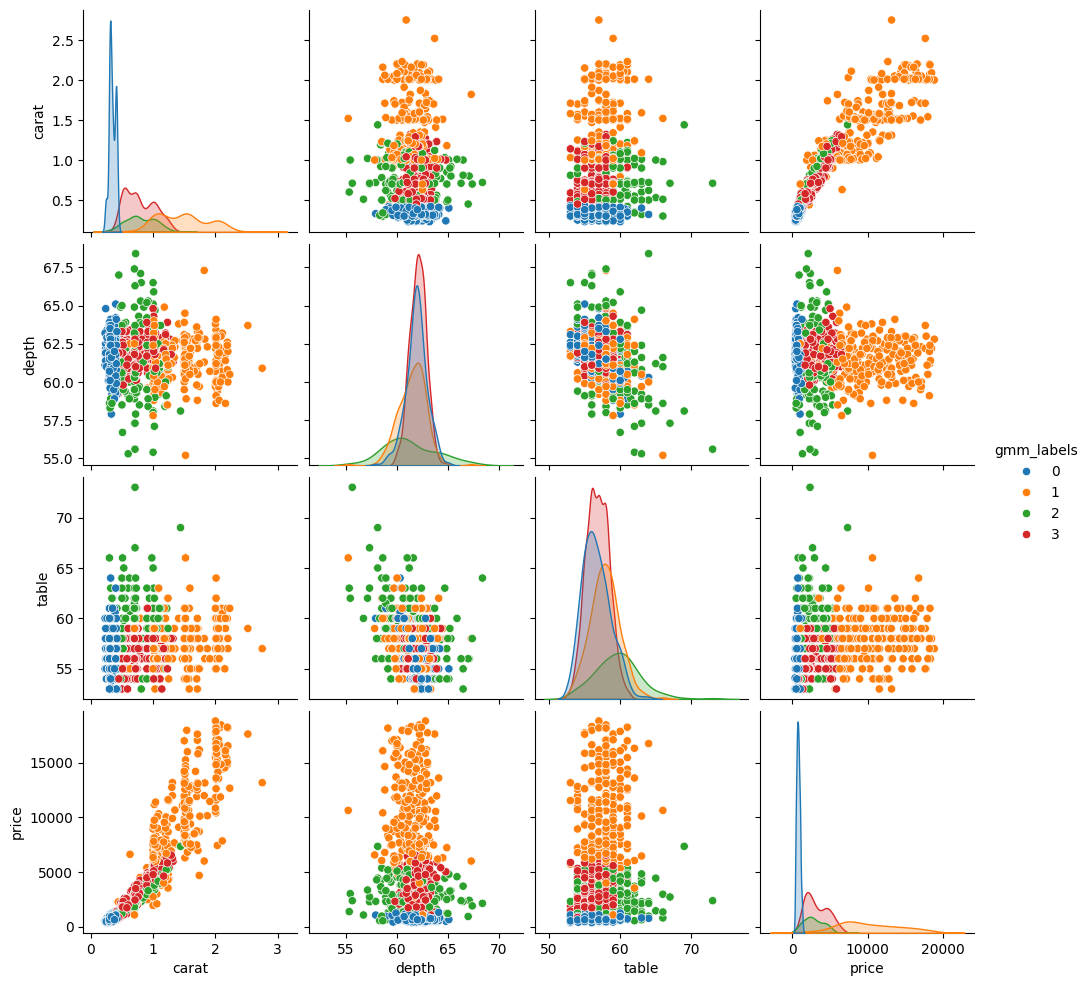

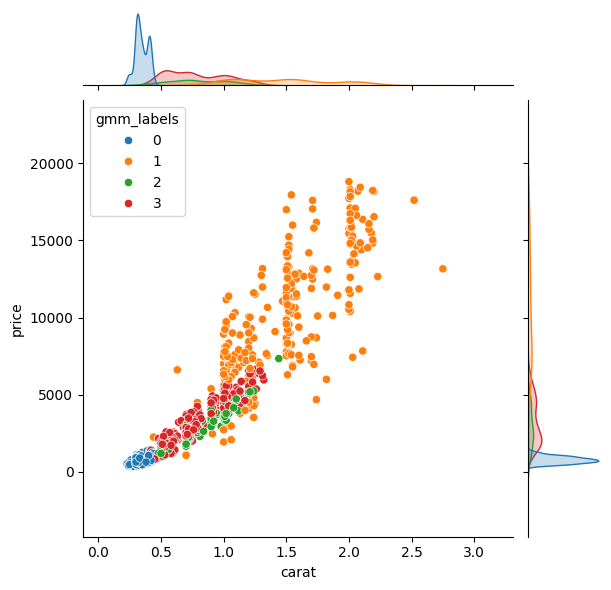

In [55]:
# f.1) Add gmm_labels to diamonds_num (unscaled)
diamonds_num['gmm_labels'] = gmm_labels
# f.2) make a pairplot
sns.pairplot(diamonds_num, vars=['carat', 'depth','table', 'price'], hue='gmm_labels', palette='tab10')
plt.show()
# f.3) make a jointplot (carat vs price)
sns.jointplot(data=diamonds_num, x='carat', y='price', hue='gmm_labels', palette='tab10')
plt.show()

**g)** In a short comment or markdown cell:
- **does the optimal number of clusters found by BIC seem reasonable when you look at the pairplot?** Yes, BIC select from 3 to 5 components
- **Would you have guessed the same number just by eye?** It's difficult to say: depth and table create a mixing cloud and and also carat-price is confusioning.
- **Did normalizing the data change the optimal number of components compared to fitting the GMM on the raw values?** Definitely. La variabile price aveva ordini di grandezza fino a 18000, mentre carat variava tra 0.2 e 3.